In [2]:
import tensorflow as tf

# Load the MNIST dataset
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.mnist.load_data()

# Normalize the data (optional, but recommended)
x_train = x_train / 255.0
x_test = x_test / 255.0

# Print shapes of the data
print(f'Train data shape: {x_train.shape}, Train labels shape: {y_train.shape}')
print(f'Test data shape: {x_test.shape}, Test labels shape: {y_test.shape}')

Train data shape: (60000, 28, 28), Train labels shape: (60000,)
Test data shape: (10000, 28, 28), Test labels shape: (10000,)


### Tensorflow CNN Tutorial

Model: "sequential_10"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d_4 (Conv2D)           (None, 26, 26, 32)        320       
                                                                 
 batch_normalization_4 (Batc  (None, 26, 26, 32)       128       
 hNormalization)                                                 
                                                                 
 max_pooling2d_4 (MaxPooling  (None, 13, 13, 32)       0         
 2D)                                                             
                                                                 
 conv2d_5 (Conv2D)           (None, 11, 11, 64)        18496     
                                                                 
 batch_normalization_5 (Batc  (None, 11, 11, 64)       256       
 hNormalization)                                                 
                                                     

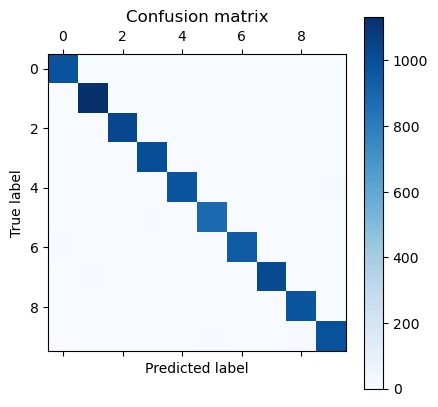

In [16]:
# Create a sequential model
model = tf.keras.models.Sequential([
    tf.keras.layers.Conv2D(32, (3, 3), activation='relu', input_shape=(28, 28, 1)),  # Convolutional layer with 32 filters
    tf.keras.layers.BatchNormalization(),  # Batch normalization
    tf.keras.layers.MaxPooling2D((2, 2)),  # Max pooling layer
    tf.keras.layers.Conv2D(64, (3, 3), activation='relu'),  # Convolutional layer with 64 filters
    tf.keras.layers.BatchNormalization(),  # Batch normalization
    tf.keras.layers.MaxPooling2D((2, 2)),  # Max pooling layer
    tf.keras.layers.Conv2D(64, (3, 3), activation='relu'),  # Convolutional layer with 64 filters
    tf.keras.layers.BatchNormalization(),  # Batch normalization
    tf.keras.layers.Flatten(),  # Flatten the input
    tf.keras.layers.Dense(64, activation='relu'),  # Dense layer with 64 units and ReLU activation
    tf.keras.layers.Dropout(0.5),  # Dropout layer with 50% rate
    tf.keras.layers.Dense(10, activation='softmax')  # Output layer with 10 units (for 10 classes) and softmax activation
])

# Early stopping callback
early_stopping = tf.keras.callbacks.EarlyStopping(patience=2)

# Compile the model
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

# Print the model summary
model.summary()

# Train the model
model.fit(x_train, y_train, epochs=100, validation_split=0.2,callbacks=[early_stopping])

# Evaluate the model
test_loss, test_acc = model.evaluate(x_test, y_test)
print(f'Test accuracy: {test_acc}')

# Export to confusion matrix
import numpy as np
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt

y_pred = np.argmax(model.predict(x_test), axis=-1)
cm = confusion_matrix(y_test, y_pred)
plt.matshow(cm, cmap='Blues')

plt.title('Confusion matrix')
plt.colorbar()
plt.ylabel('True label')
plt.xlabel('Predicted label')
plt.show()


## Models Best Models from Literature